In [9]:
# 3D Loss Surface Analysis: Total vs Local Derivatives
# This notebook explores how the number of integration points affects derivative computation

using Plots
using LinearAlgebra
using Statistics
using Random

# Set random seed for reproducibility
Random.seed!(42)

# Enable 3D plotting
plotlyjs()

Plots.PlotlyJSBackend()

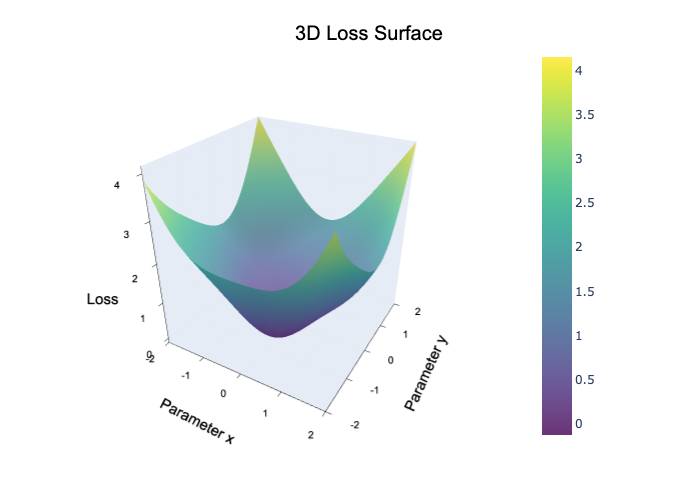

In [10]:
# Define a simple 3D loss surface (paraboloid with some complexity)
function loss_surface(x, y)
    # A more interesting loss surface with multiple minima
    z1 = 0.5 * (x^2 + y^2)  # Main paraboloid
    z2 = 0.3 * sin(2*x) * cos(2*y)  # Oscillatory component
    z3 = 0.1 * exp(-(x-1)^2 - (y+0.5)^2)  # Local bump
    return z1 + z2 + z3
end

# Analytical derivatives
function analytical_gradient(x, y)
    # ∂z/∂x
    dx = x + 0.6 * cos(2*x) * cos(2*y) - 0.2 * (x-1) * exp(-(x-1)^2 - (y+0.5)^2)
    # ∂z/∂y  
    dy = y - 0.6 * sin(2*x) * sin(2*y) - 0.2 * (y+0.5) * exp(-(x-1)^2 - (y+0.5)^2)
    return [dx, dy]
end

# Create meshgrid for visualization
x_range = range(-2, 2, length=50)
y_range = range(-2, 2, length=50)
X = [x for x in x_range, y in y_range]
Y = [y for x in x_range, y in y_range]
Z = [loss_surface(x, y) for x in x_range, y in y_range]

# Plot the loss surface
p_surface = surface(x_range, y_range, Z, 
                   title="3D Loss Surface",
                   xlabel="Parameter x", 
                   ylabel="Parameter y", 
                   zlabel="Loss",
                   colormap=:viridis,
                   alpha=0.8)

display(p_surface)

In [11]:
# Simulate trajectory-based derivative computation
# This mimics how gradients are computed over trajectory windows

function compute_trajectory_loss(x_param, y_param, n_points, noise_level=0.01)
    """
    Simulate computing loss over n_points of a trajectory
    In real case, this would be integration steps
    """
    total_loss = 0.0
    
    # Simulate n_points along a trajectory path
    for i in 1:n_points
        # Simulate trajectory progression (spiral path)
        t = i / n_points * 2π
        x_traj = x_param + 0.1 * cos(t)
        y_traj = y_param + 0.1 * sin(t)
        
        # Add measurement noise
        noise_x = noise_level * randn()
        noise_y = noise_level * randn()
        
        # Accumulate loss at this trajectory point
        point_loss = loss_surface(x_traj + noise_x, y_traj + noise_y)
        total_loss += point_loss
    end
    
    return total_loss / n_points  # Average loss
end

function numerical_gradient(x, y, n_points, h=1e-6)
    """
    Compute numerical gradient using finite differences
    over n_points trajectory points
    """
    f_x_plus = compute_trajectory_loss(x + h, y, n_points)
    f_x_minus = compute_trajectory_loss(x - h, y, n_points)
    f_y_plus = compute_trajectory_loss(x, y + h, n_points)
    f_y_minus = compute_trajectory_loss(x, y - h, n_points)
    
    dx = (f_x_plus - f_x_minus) / (2 * h)
    dy = (f_y_plus - f_y_minus) / (2 * h)
    
    return [dx, dy]
end

# Test different numbers of integration points
point_counts = [1, 5, 10, 50, 100, 500]
test_points = [(0.5, 0.3), (-0.8, 0.7), (1.2, -0.5), (-1.1, -1.0)]

println("Gradient Analysis: Effect of Integration Points")
println("=" ^ 60)

Gradient Analysis: Effect of Integration Points


In [12]:
# Analyze gradient behavior for different point counts
gradient_results = Dict()

for n_points in point_counts
    println("\nAnalyzing with $n_points integration points:")
    println("-" ^ 40)
    
    gradients_numerical = []
    gradients_analytical = []
    errors = []
    
    for (x, y) in test_points
        # Compute numerical gradient over n_points
        grad_num = numerical_gradient(x, y, n_points)
        
        # Compute analytical gradient (truth)
        grad_analytical = analytical_gradient(x, y)
        
        # Compute error
        error = norm(grad_num - grad_analytical)
        
        push!(gradients_numerical, grad_num)
        push!(gradients_analytical, grad_analytical)
        push!(errors, error)
        
        println("Point ($x, $y): Numerical = $(round.(grad_num, digits=4)), " *
                "Analytical = $(round.(grad_analytical, digits=4)), " *
                "Error = $(round(error, digits=6))")
    end
    
    gradient_results[n_points] = (
        numerical = gradients_numerical,
        analytical = gradients_analytical, 
        errors = errors,
        mean_error = mean(errors)
    )
    
    println("Mean error: $(round(gradient_results[n_points].mean_error, digits=6))")
end




Analyzing with 1 integration points:
----------------------------------------
Point (0.5, 0.3): Numerical = [6861.9943, 1156.7037], Analytical = [0.8086, -0.0508], Error = 6958.013318
Point (-0.8, 0.7): Numerical = [3075.0001, 7157.1999], Analytical = [-0.7996, 1.2888], Error = 7788.941367
Point (1.2, -0.5): Numerical = [-6332.6402, -3667.1789], Analytical = [0.9225, -0.159], Error = 7318.541704
Point (-1.1, -1.0): Numerical = [16448.6804, 11218.9785], Analytical = [-0.9491, -1.4402], Error = 19912.009024
Mean error: 10494.376353

Analyzing with 5 integration points:
----------------------------------------
Point (0.5, 0.3): Numerical = [-752.0747, -380.733], Analytical = [0.8086, -0.0508], Error = 843.654135
Point (-0.8, 0.7): Numerical = [-2306.0761, -1710.481], Analytical = [-0.7996, 1.2888], Error = 2871.315976
Point (1.2, -0.5): Numerical = [-916.442, 1048.3798], Analytical = [0.9225, -0.159], Error = 1393.194599
Point (-1.1, -1.0): Numerical = [-2182.0953, 2396.0824], Analytical

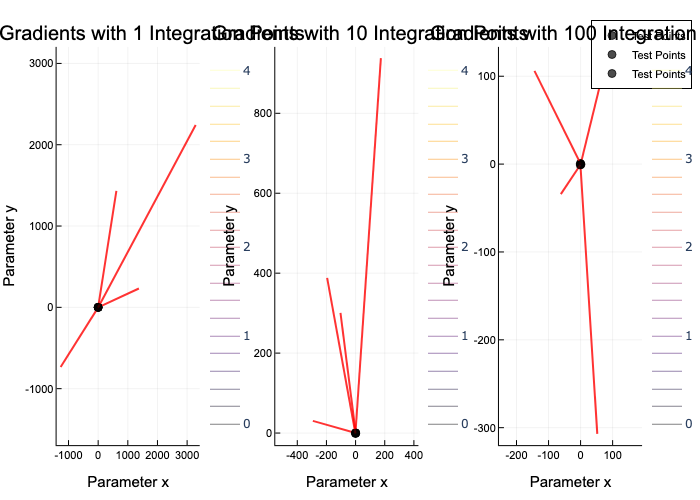

In [13]:
# Visualize gradient vectors on the loss surface
function plot_gradients_3d(n_points_list=[1, 10, 100])
    plots = []
    
    for n_points in n_points_list
        # Create contour plot of loss surface
        p = contour(x_range, y_range, Z, 
                   levels=20,
                   title="Gradients with $n_points Integration Points",
                   xlabel="Parameter x",
                   ylabel="Parameter y",
                   aspect_ratio=:equal,
                   size=(400, 400))
        
        # Add gradient vectors for test points
        for (i, (x, y)) in enumerate(test_points)
            # Numerical gradient
            grad_num = gradient_results[n_points].numerical[i]
            # Analytical gradient  
            grad_analytical = gradient_results[n_points].analytical[i]
            
            # Scale gradients for visibility
            scale = 0.2
            
            # Plot numerical gradient (red)
            quiver!(p, [x], [y], 
                   quiver=([grad_num[1] * scale], [grad_num[2] * scale]),
                   color=:red, linewidth=2, alpha=0.8,
                   label=(i == 1 ? "Numerical" : ""))
            
            # Plot analytical gradient (blue)  
            quiver!(p, [x], [y],
                   quiver=([grad_analytical[1] * scale], [grad_analytical[2] * scale]), 
                   color=:blue, linewidth=2, alpha=0.8,
                   label=(i == 1 ? "Analytical" : ""))
            
            # Mark test points
            scatter!(p, [x], [y], color=:black, markersize=4, alpha=0.7,
                    label=(i == 1 ? "Test Points" : ""))
        end
        
        push!(plots, p)
    end
    
    return plot(plots..., layout=(1, length(n_points_list)), size=(1200, 400))
end

p_gradients = plot_gradients_3d([1, 10, 100])
display(p_gradients)

In [14]:
# Error analysis: How error changes with number of integration points
error_data = [gradient_results[n].mean_error for n in point_counts]

p_error = plot(point_counts, error_data,
              xaxis=:log10, yaxis=:log10,
              marker=:circle, markersize=6,
              linewidth=2,
              title="Gradient Error vs Integration Points",
              xlabel="Number of Integration Points", 
              ylabel="Mean Gradient Error",
              label="Mean Error",
              grid=true)

# Add trend line
z = polyfit(log10.(point_counts), log10.(error_data), 1)
trend_y = 10 .^ (z[1] .* log10.(point_counts) .+ z[2])
plot!(p_error, point_counts, trend_y, 
      linestyle=:dash, color=:red, linewidth=2,
      label="Trend (slope ≈ $(round(z[1], digits=2)))")

display(p_error)

UndefVarError: UndefVarError: `polyfit` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

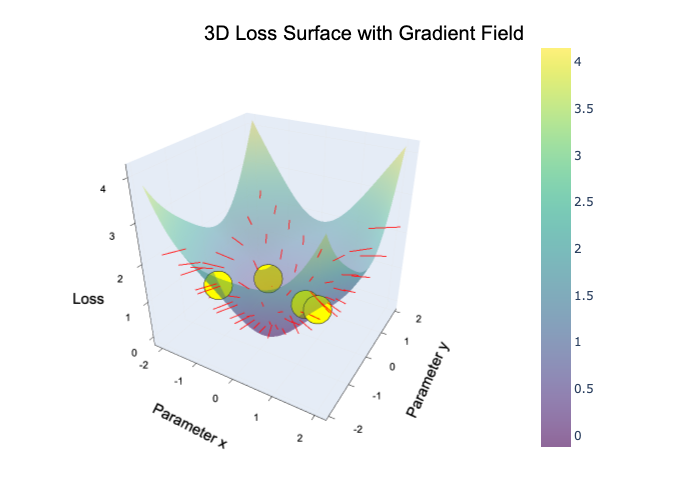

In [15]:
# 3D visualization: Gradient field on loss surface
function plot_3d_gradient_field()
    # Sample points for gradient field
    x_sparse = range(-1.5, 1.5, length=8)
    y_sparse = range(-1.5, 1.5, length=8)
    
    # Create 3D surface plot
    p3d = surface(x_range, y_range, Z,
                 title="3D Loss Surface with Gradient Field",
                 xlabel="Parameter x",
                 ylabel="Parameter y", 
                 zlabel="Loss",
                 colormap=:viridis,
                 alpha=0.6,
                 size=(800, 600))
    
    # Add gradient vectors in 3D
    for x in x_sparse, y in y_sparse
        z = loss_surface(x, y)
        grad = analytical_gradient(x, y)
        
        # Scale for visibility
        scale = 0.3
        
        # Add 3D arrow (gradient in x-y plane)
        plot!(p3d, [x, x + grad[1] * scale], [y, y + grad[2] * scale], [z, z],
              color=:red, linewidth=2, alpha=0.8, label="")
    end
    
    # Highlight test points
    for (x, y) in test_points
        z = loss_surface(x, y)
        scatter!(p3d, [x], [y], [z], 
                color=:yellow, markersize=8, alpha=1.0, label="")
    end
    
    return p3d
end

p3d_field = plot_3d_gradient_field()
display(p3d_field)

In [16]:
# Comparison of local vs total derivatives
function compare_local_vs_total()
    # Choose a specific test point
    x₀, y₀ = 0.5, 0.3
    
    # Local derivative (single point)
    grad_local = analytical_gradient(x₀, y₀)
    
    # Total derivatives with different integration lengths
    comparison_data = []
    
    for n_points in [1, 5, 10, 25, 50, 100, 200, 500]
        grad_total = numerical_gradient(x₀, y₀, n_points)
        
        # Compute angle difference
        angle_diff = acos(clamp(dot(grad_local, grad_total) / 
                               (norm(grad_local) * norm(grad_total)), -1, 1))
        angle_diff_deg = rad2deg(angle_diff)
        
        # Magnitude ratio
        mag_ratio = norm(grad_total) / norm(grad_local)
        
        push!(comparison_data, (
            n_points = n_points,
            grad_total = grad_total,
            angle_diff = angle_diff_deg,
            mag_ratio = mag_ratio
        ))
        
        println("$n_points points: Total grad = $(round.(grad_total, digits=4)), " *
                "Angle diff = $(round(angle_diff_deg, digits=2))°, " *
                "Mag ratio = $(round(mag_ratio, digits=3))")
    end
    
    return comparison_data
end

println("Local vs Total Derivative Comparison at point (0.5, 0.3):")
println("Local gradient: $(round.(analytical_gradient(0.5, 0.3), digits=4))")
println()
comparison_data = compare_local_vs_total()

Local vs Total Derivative Comparison at point (0.5, 0.3):
Local gradient: [0.8086, -0.0508]

1 points: Total grad = [-11942.5248, -5592.4889], Angle diff = 151.31°, Mag ratio = 16276.019
5 points: Total grad = [-2700.5947, -1465.929], Angle diff = 147.91°, Mag ratio = 3792.576
10 points: Total grad = [-854.8675, -298.5229], Angle diff = 157.16°, Mag ratio = 1117.591
25 points: Total grad = [146.2779, 2279.3837], Angle diff = 89.92°, Mag ratio = 2819.087
50 points: Total grad = [-837.0673, -754.2382], Angle diff = 134.39°, Mag ratio = 1390.672
100 points: Total grad = [-539.031, 599.0801], Angle diff = 135.57°, Mag ratio = 994.654
200 points: Total grad = [564.2382, -496.616], Angle diff = 37.76°, Mag ratio = 927.726
500 points: Total grad = [141.1976, 88.7445], Angle diff = 35.74°, Mag ratio = 205.834


8-element Vector{Any}:
 (n_points = 1, grad_total = [-11942.52477467514, -5592.488876792229], angle_diff = 151.3135154810293, mag_ratio = 16276.018799298263)
 (n_points = 5, grad_total = [-2700.594725027733, -1465.929016773282], angle_diff = 147.91257229434464, mag_ratio = 3792.575858771403)
 (n_points = 10, grad_total = [-854.8675015353225, -298.5228617609914], angle_diff = 157.15705051569307, mag_ratio = 1117.5908732148657)
 (n_points = 25, grad_total = [146.2779159649985, 2279.383743771624], angle_diff = 89.92167798335466, mag_ratio = 2819.087147163149)
 (n_points = 50, grad_total = [-837.0672893989184, -754.2382173675311], angle_diff = 134.38605384942727, mag_ratio = 1390.671951570672)
 (n_points = 100, grad_total = [-539.0310075581717, 599.080116216566], angle_diff = 135.57331697859328, mag_ratio = 994.6537795305914)
 (n_points = 200, grad_total = [564.2381672091024, -496.6159514050439], angle_diff = 37.75915843870642, mag_ratio = 927.726146715636)
 (n_points = 500, grad_total = [